# Part 1: Neural Network Fundamentals and Training Behavior Analysis

**Problem:** Predict whether a customer is likely to churn using a feed-forward neural network.

This notebook covers:

1. Dataset understanding  
2. Data preprocessing  
3. Neural network model building  
4. Training and evaluation  
5. Hyperparameter experimentation  
6. Final reflection on how neural networks learn

## 1. Import Libraries and Set Up Paths

PyTorch is used because it allows the forward pass, loss calculation, backpropagation, and optimizer step to be shown directly.

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

DATA_PATH = Path("data/customer_churn_nn.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("customer_churn_nn.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/customer_churn_nn.csv")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Dataset path:", DATA_PATH)

Dataset path: data\customer_churn_nn.csv


## 2. Task 1: Dataset Understanding

The first step is to understand the number of observations, the input feature types, the target variable, missing values, and the distribution of the target class.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Number of rows and columns:", df.shape)
display(df.head())

Number of rows and columns: (2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [17]:
print("Column data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values per column:")
display(df.isna().sum().to_frame("missing_values"))

Column data types:


,dtype
customer_id,str
region,str
plan_type,str
contract_type,str
payment_method,str
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


Missing values per column:


,missing_values
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [5]:
print("Basic statistical summary for numerical columns:")
display(df.describe().T)

Basic statistical summary for numerical columns:


,count,mean,std,min,25%,50%,75%,max
tenure_months,2000.0,25.362000,14.128651,1.00,15.0000,23.000,33.0000,72.00
monthly_charges_inr,2000.0,766.487295,393.420070,255.45,427.7825,688.355,1007.3725,2156.52
avg_login_days_per_month,2000.0,18.099000,5.400628,0.00,15.0000,18.000,22.0000,30.00
support_tickets_last_90_days,2000.0,1.953000,1.463852,0.00,1.0000,2.000,3.0000,8.00
payment_delay_days,2000.0,3.555000,3.885682,0.00,1.0000,2.000,5.0000,31.00
data_usage_gb,2000.0,90.007625,53.215719,0.50,51.7775,80.245,119.0975,265.51
satisfaction_score,2000.0,6.873950,1.524280,1.00,5.8750,6.800,8.0000,10.00
last_complaint_days_ago,2000.0,46.616500,55.065775,0.00,6.0000,28.500,68.0000,424.00
discount_percent,2000.0,8.255000,7.553708,0.00,0.0000,5.000,15.0000,20.00
autopay_enabled,2000.0,0.597500,0.490524,0.00,0.0000,1.000,1.0000,1.00


,count,percentage
churn,,
0,1969,98.45
1,31,1.55


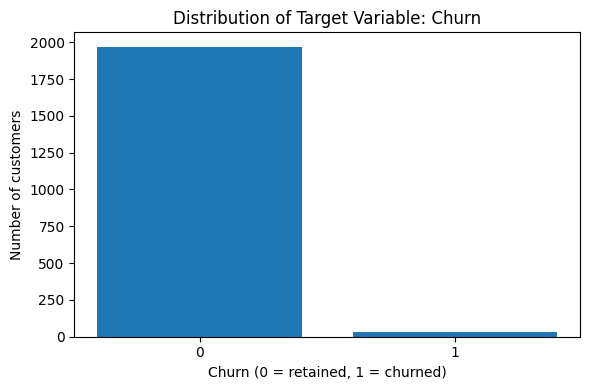

In [6]:
target_counts = df["churn"].value_counts().sort_index()
target_percent = (target_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

display(target_summary)

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Distribution of Target Variable: Churn")
plt.xlabel("Churn (0 = retained, 1 = churned)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

### Dataset Understanding Summary

- The target variable is `churn`, where `1` means the customer churned and `0` means the customer was retained.
- `customer_id` is an identifier and is removed before model training because it does not carry behavioural meaning.
- The dataset contains both numerical and categorical input features.
- The target distribution is highly imbalanced, so accuracy alone is not enough to judge the model. Precision, recall, F1 score, ROC-AUC, and the confusion matrix are also needed.

## 3. Task 2: Data Preprocessing

Preprocessing steps:

1. Remove the identifier column `customer_id`.
2. Separate features and target.
3. Identify categorical and numerical columns.
4. Impute missing values if they appear.
5. One-hot encode categorical columns.
6. Scale numerical columns.
7. Split data into training and testing sets using stratification.

In [7]:
TARGET = "churn"
ID_COL = "customer_id"

X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET].astype(np.float32)

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [8]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibility for older scikit-learn versions
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:")
display(pd.Series(y_train_np).value_counts().sort_index())
print("Testing target distribution:")
display(pd.Series(y_test_np).value_counts().sort_index())

Training set shape: (1600, 28)
Testing set shape: (400, 28)
Training target distribution:


0.0    1575
1.0      25
Name: count, dtype: int64

Testing target distribution:


0.0    394
1.0      6
Name: count, dtype: int64

## 4. Task 3: Neural Network Model Building

For binary churn prediction, the model uses:

- **Input layer:** number of neurons equals the number of processed features.
- **Hidden layer(s):** one or more dense layers.
- **Activation function:** ReLU or Tanh.
- **Output layer:** one neuron producing a logit.
- **Loss function:** Binary Cross-Entropy with Logits Loss.
- **Optimizer:** Adam.

Because the churn class is rare, `pos_weight` is used in the loss function so that mistakes on churned customers are penalised more heavily.

In [9]:
class ChurnNN(nn.Module):
    def __init__(self, input_dim, hidden_layers=(16,), activation="relu"):
        super().__init__()
        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid,
        }

        layers = []
        previous_dim = input_dim

        for hidden_units in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_units))
            layers.append(activation_map[activation]())
            previous_dim = hidden_units

        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)

input_dim = X_train.shape[1]
example_model = ChurnNN(input_dim=input_dim, hidden_layers=(16,), activation="relu")
print(example_model)

ChurnNN(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 5. Showing How the Neural Network Learns

This small demonstration shows the learning process explicitly:

1. A forward pass produces logits.
2. The loss function compares predictions with actual labels.
3. Backpropagation calculates gradients.
4. The optimizer updates weights and biases.

In [10]:
X_demo = torch.tensor(X_train[:8], dtype=torch.float32)
y_demo = torch.tensor(y_train_np[:8], dtype=torch.float32)

demo_model = ChurnNN(input_dim=input_dim, hidden_layers=(16,), activation="relu")

# Weight values before one update
first_layer_weight_before = demo_model.network[0].weight.detach().clone()
first_layer_bias_before = demo_model.network[0].bias.detach().clone()

# Class weighting for the rare churn class
positive_count = (y_train_np == 1).sum()
negative_count = (y_train_np == 0).sum()
pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32)

loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(demo_model.parameters(), lr=0.001)

# 1. Forward pass
logits = demo_model(X_demo)
probabilities = torch.sigmoid(logits)

# 2. Loss calculation
loss = loss_function(logits, y_demo)

# 3. Backpropagation
optimizer.zero_grad()
loss.backward()

# Gradient from first layer after backpropagation
first_layer_gradient_norm = demo_model.network[0].weight.grad.norm().item()

# 4. Parameter update
optimizer.step()

first_layer_weight_after = demo_model.network[0].weight.detach().clone()
first_layer_bias_after = demo_model.network[0].bias.detach().clone()

weight_change = (first_layer_weight_after - first_layer_weight_before).abs().mean().item()
bias_change = (first_layer_bias_after - first_layer_bias_before).abs().mean().item()

print("Predicted probabilities before update:", probabilities.detach().numpy().round(4))
print("Loss before update:", round(loss.item(), 4))
print("First-layer gradient norm:", round(first_layer_gradient_norm, 6))
print("Average absolute weight change after one optimizer step:", round(weight_change, 8))
print("Average absolute bias change after one optimizer step:", round(bias_change, 8))

Predicted probabilities before update: [0.5075 0.4957 0.5476 0.4833 0.4902 0.4734 0.5147 0.542 ]
Loss before update: 0.7081
First-layer gradient norm: 0.350058
Average absolute weight change after one optimizer step: 0.00070759
Average absolute bias change after one optimizer step: 0.001


The non-zero gradient and the changed weights/biases show that the network has learned from the error signal. Over many epochs, this repeated process gradually changes the model parameters so that the predictions fit the training data better.

## 6. Task 4 and Task 5: Training, Evaluation, and Hyperparameter Experiments

The function below trains the neural network and returns evaluation metrics. Five experiments are run by changing hidden layers, neurons, learning rate, and activation function.

In [11]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


def train_and_evaluate(config):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = ChurnNN(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        activation=config["activation"]
    )

    positive_count = (y_train_np == 1).sum()
    negative_count = (y_train_np == 0).sum()
    pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    generator = torch.Generator().manual_seed(SEED)
    loader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        generator=generator
    )

    training_losses = []

    for epoch in range(config["epochs"]):
        model.train()
        epoch_loss = 0.0

        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_X)

        training_losses.append(epoch_loss / len(dataset))

    model.eval()
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train_tensor)).numpy()
        test_probs = torch.sigmoid(model(X_test_tensor)).numpy()

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics = {
        "Training Accuracy": accuracy_score(y_train_np, train_preds),
        "Training Loss": training_losses[-1],
        "Testing Accuracy": accuracy_score(y_test_np, test_preds),
        "Testing Loss": log_loss(y_test_np, test_probs, labels=[0, 1]),
        "Precision": precision_score(y_test_np, test_preds, zero_division=0),
        "Recall": recall_score(y_test_np, test_preds, zero_division=0),
        "F1 Score": f1_score(y_test_np, test_preds, zero_division=0),
        "ROC AUC": roc_auc_score(y_test_np, test_probs),
        "Positive Predictions": int(test_preds.sum()),
        "Confusion Matrix": confusion_matrix(y_test_np, test_preds).tolist(),
    }

    return model, training_losses, test_probs, test_preds, metrics

In [12]:
experiments = [
    {
        "Experiment": "Baseline: 1 hidden layer",
        "hidden_layers": (16,),
        "activation": "relu",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 50,
    },
    {
        "Experiment": "Wider: 32 neurons",
        "hidden_layers": (32,),
        "activation": "relu",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 50,
    },
    {
        "Experiment": "Deeper: 32 and 16 neurons",
        "hidden_layers": (32, 16),
        "activation": "relu",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 50,
    },
    {
        "Experiment": "Lower learning rate",
        "hidden_layers": (32, 16),
        "activation": "relu",
        "learning_rate": 0.0001,
        "batch_size": 32,
        "epochs": 50,
    },
    {
        "Experiment": "Tanh activation",
        "hidden_layers": (32, 16),
        "activation": "tanh",
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 50,
    },
]

all_results = []
trained_objects = {}

for config in experiments:
    model, losses, test_probs, test_preds, metrics = train_and_evaluate(config)

    row = {
        "Experiment": config["Experiment"],
        "Hidden Layers / Neurons": str(config["hidden_layers"]),
        "Activation": config["activation"],
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Epochs": config["epochs"],
        **metrics,
    }
    all_results.append(row)
    trained_objects[config["Experiment"]] = {
        "model": model,
        "losses": losses,
        "test_probs": test_probs,
        "test_preds": test_preds,
        "metrics": metrics,
        "config": config,
    }

comparison_df = pd.DataFrame(all_results)
comparison_display = comparison_df.drop(columns=["Confusion Matrix"]).copy()

numeric_cols_to_round = [
    "Training Accuracy", "Training Loss", "Testing Accuracy", "Testing Loss",
    "Precision", "Recall", "F1 Score", "ROC AUC"
]
comparison_display[numeric_cols_to_round] = comparison_display[numeric_cols_to_round].round(4)

display(comparison_display)

,Experiment,Hidden Layers / Neurons,Activation,Learning Rate,Batch Size,Epochs,Training Accuracy,Training Loss,Testing Accuracy,Testing Loss,Precision,Recall,F1 Score,ROC AUC,Positive Predictions
0,Baseline: 1 hidden layer,"(16,)",relu,0.0010,32,50,0.9031,0.3688,0.9175,0.2347,0.1143,0.6667,0.1951,0.8405,35
1,Wider: 32 neurons,"(32,)",relu,0.0010,32,50,0.9319,0.2707,0.9200,0.1871,0.0938,0.5000,0.1579,0.8113,32
2,Deeper: 32 and 16 neurons,"(32, 16)",relu,0.0010,32,50,0.9906,0.0488,0.9775,0.1283,0.2000,0.1667,0.1818,0.7707,5
3,Lower learning rate,"(32, 16)",relu,0.0001,32,50,0.7994,0.8581,0.7975,0.4273,0.0588,0.8333,0.1099,0.9251,85
4,Tanh activation,"(32, 16)",tanh,0.0010,32,50,0.8731,0.4667,0.8800,0.3086,0.0962,0.8333,0.1724,0.8139,52


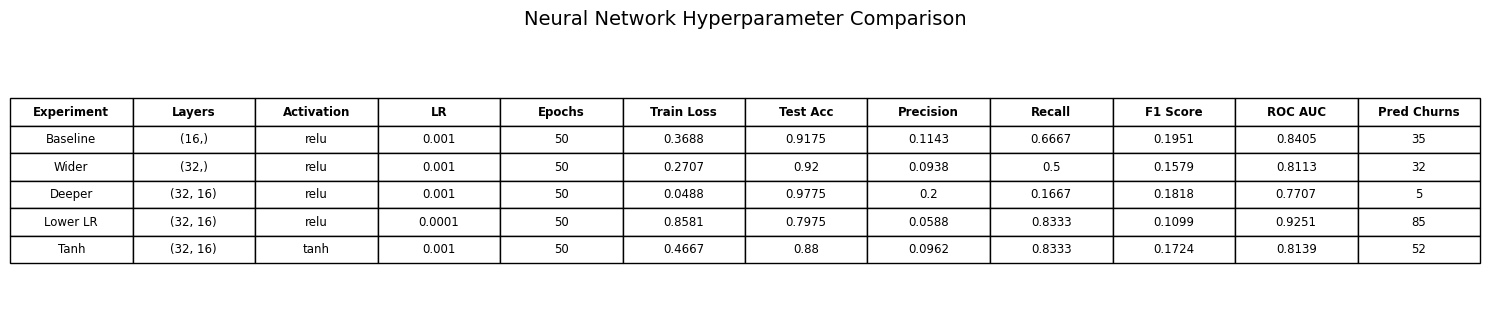

In [13]:
comparison_df.to_csv(RESULTS_DIR / "model_comparison_table.csv", index=False)

# Shorter table for the PNG so it remains readable.
table_for_image = comparison_df.drop(columns=["Confusion Matrix"]).copy()
table_for_image = table_for_image.rename(columns={
    "Hidden Layers / Neurons": "Layers",
    "Learning Rate": "LR",
    "Training Accuracy": "Train Acc",
    "Training Loss": "Train Loss",
    "Testing Accuracy": "Test Acc",
    "Testing Loss": "Test Loss",
    "Positive Predictions": "Pred Churns",
})

table_for_image = table_for_image[[
    "Experiment", "Layers", "Activation", "LR", "Epochs", "Train Loss",
    "Test Acc", "Precision", "Recall", "F1 Score", "ROC AUC", "Pred Churns"
]]

table_for_image["Experiment"] = table_for_image["Experiment"].replace({
    "Baseline: 1 hidden layer": "Baseline",
    "Wider: 32 neurons": "Wider",
    "Deeper: 32 and 16 neurons": "Deeper",
    "Lower learning rate": "Lower LR",
    "Tanh activation": "Tanh",
})

for col in ["LR", "Train Loss", "Test Acc", "Precision", "Recall", "F1 Score", "ROC AUC"]:
    table_for_image[col] = table_for_image[col].astype(float).round(4)

fig, ax = plt.subplots(figsize=(15, 3.4))
ax.axis("off")

table = ax.table(
    cellText=table_for_image.astype(str).values,
    colLabels=table_for_image.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

plt.title("Neural Network Hyperparameter Comparison", pad=12, fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison_table.png", dpi=220, bbox_inches="tight")
plt.show()

## 7. Evaluation of Selected Model

The selected model is chosen using F1 score because the dataset is heavily imbalanced. Accuracy is still reported, but it should not be treated as the main success measure.

In [14]:
best_row = comparison_df.sort_values(
    by=["F1 Score", "ROC AUC"],
    ascending=False
).iloc[0]

best_experiment = best_row["Experiment"]
best_object = trained_objects[best_experiment]

print("Selected experiment:", best_experiment)
print("Reason: highest F1 score, with ROC-AUC used as a secondary check.")
print("Confusion matrix:", best_object["metrics"]["Confusion Matrix"])

print("Classification report:")
print(classification_report(y_test_np, best_object["test_preds"], zero_division=0))

Selected experiment: Baseline: 1 hidden layer
Reason: highest F1 score, with ROC-AUC used as a secondary check.
Confusion matrix: [[363, 31], [2, 4]]
Classification report:
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.96       394
         1.0       0.11      0.67      0.20         6

    accuracy                           0.92       400
   macro avg       0.55      0.79      0.58       400
weighted avg       0.98      0.92      0.95       400



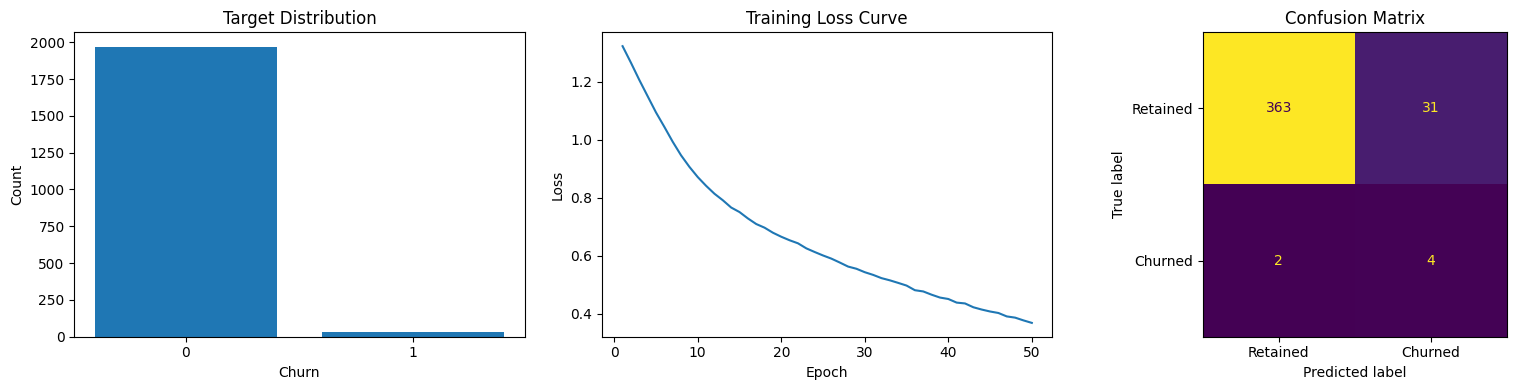

In [15]:
cm = confusion_matrix(y_test_np, best_object["test_preds"])
losses = best_object["losses"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
axes[0].bar(target_counts.index.astype(str), target_counts.values)
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

# Training loss curve
axes[1].plot(range(1, len(losses) + 1), losses)
axes[1].set_title("Training Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

# Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "evaluation_outputs.png", dpi=200, bbox_inches="tight")
plt.show()

### Brief Interpretation of Result

The model achieves high overall accuracy, but this is partly because the dataset contains many more retained customers than churned customers. The more useful result is the trade-off between recall and precision for the churn class. A model with class-weighted loss is better at identifying churned customers, but it also produces more false positives. In a real business setting, this could still be acceptable if the cost of contacting a non-churning customer is lower than the cost of losing a customer.

The deeper model showed signs of fitting the training data more aggressively. Its training loss became very low, but its churn recall on the test set was weaker. This suggests that adding more layers can increase model capacity, but it does not automatically improve generalisation, especially when the positive class is rare.

## Saved Result Files

The repository also includes pre-generated outputs in the `results/` folder:

![Model comparison table](results/model_comparison_table.png)

![Evaluation outputs](results/evaluation_outputs.png)

Key values from this run:

- Dataset size: **2000 rows × 17 columns**
- Target split: **1969 retained customers** and **31 churned customers**
- Selected model: **Baseline: 1 hidden layer**
- Selected model confusion matrix: **[[363, 31], [2, 4]]**
- Main limitation: churn is rare, so accuracy is not enough; recall and F1 score matter more.

## 8. Task 6: Final Reflection

### What role do weights and biases play in the model?

Weights decide how strongly each input feature influences the next layer. Biases shift the activation value so that the model is not forced to pass through zero. During training, the model changes weights and biases to reduce the loss. In this churn model, the network adjusts these parameters to learn patterns linked with customers who are more likely to leave.

### Why is an activation function required?

Without activation functions, multiple neural network layers would collapse into one linear transformation. The activation function adds non-linearity, allowing the model to learn more complex relationships between features such as contract type, payment delay, satisfaction score, and churn. ReLU was used because it is simple and commonly works well, while Tanh was tested as an alternative.

### What happens when the learning rate is too high or too low?

The learning rate controls the size of each parameter update. If it is too high, the model may jump around the loss surface and fail to settle into a good solution. If it is too low, training becomes slow and the model may underfit within the given number of epochs. In the experiments, the lower learning rate produced weaker learning behaviour within 50 epochs because the model updated too cautiously.

### Did the model show signs of underfitting or overfitting?

Some underfitting appeared in configurations that learned too slowly or made too many positive predictions. Some overfitting appeared in the deeper network because training performance improved strongly, but test churn detection did not improve in the same way. The main difficulty, however, is class imbalance. Since churn cases are very rare, the model can get high accuracy while still struggling to identify the minority class. That is why recall, F1 score, ROC-AUC, and the confusion matrix are more honest than accuracy alone.